In [ ]:
!pip install nbformat

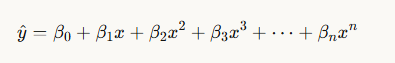

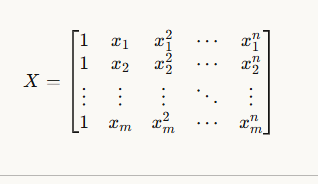

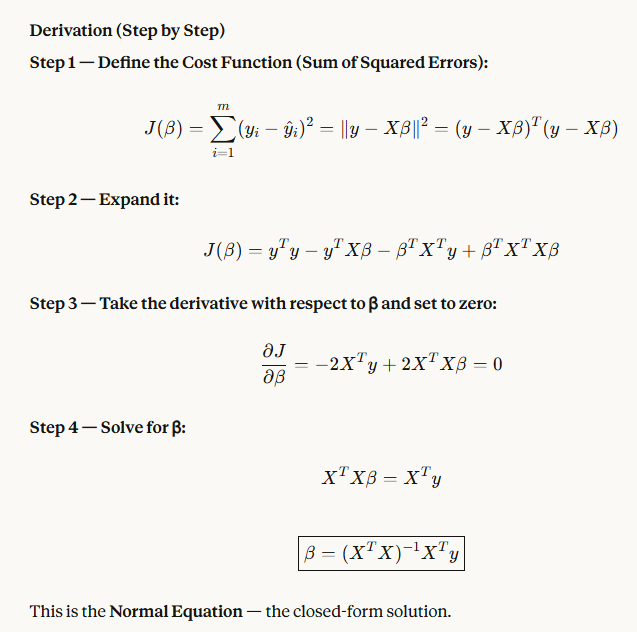

Coefficients β: [1.25       0.70530303 0.34469697]
β₀=1.2500, β₁=0.7053, β₂=0.3447
R² Score: 0.9981


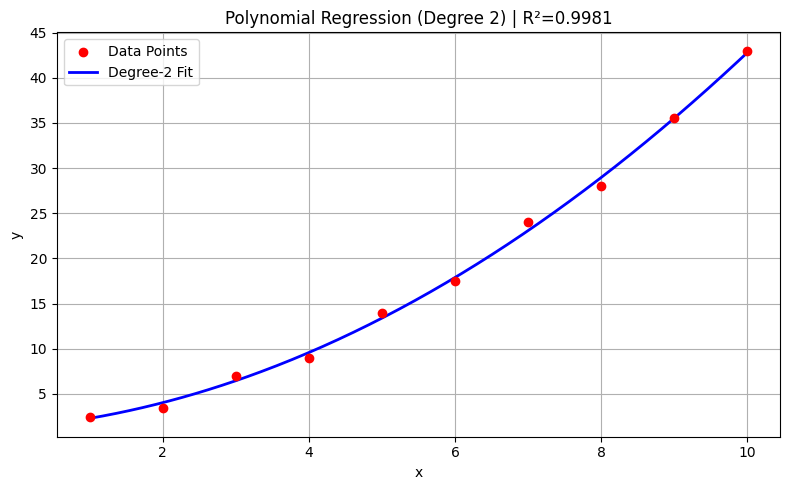

In [9]:
import numpy as np
import matplotlib.pyplot as plt
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
y = np.array([2.5, 3.5, 7.0, 9.0, 14.0, 17.5, 24.0, 28.0, 35.5, 43.0])
degree = 2

# Columns: [1, x, x², x³, ..., x^degree]
X = np.column_stack([x**i for i in range(degree + 1)])
beta = np.linalg.inv(X.T @ X) @ X.T @ y
print(f"Coefficients β: {beta}")
print(f"β₀={beta[0]:.4f}, β₁={beta[1]:.4f}, β₂={beta[2]:.4f}")

# ── 5. Predict ───────────────────────────────────────────────────
x_line = np.linspace(1, 10, 300)
X_line = np.column_stack([x_line**i for i in range(degree + 1)])
y_pred = X_line @ beta

# ── 6. R² Score ──────────────────────────────────────────────────
y_hat = X @ beta
ss_res = np.sum((y - y_hat) ** 2)          # Residual Sum of Squares
ss_tot = np.sum((y - np.mean(y)) ** 2)     # Total Sum of Squares
r2 = 1 - (ss_res / ss_tot)
print(f"R² Score: {r2:.4f}")

# ── 7. Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='red', zorder=5, label='Data Points')
plt.plot(x_line, y_pred, color='blue', linewidth=2, label=f'Degree-{degree} Fit')
plt.title(f'Polynomial Regression (Degree {degree}) | R²={r2:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()